<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/ANALISE_ESPACIAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Espacial Utilizando o Python

In [1]:
# BIBLIOTECAS
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import folium
import mapclassify
import branca.colormap as cm
import os
import numpy as np

# **Carregar os dados**

Google Drive

     ↓

gdown

     ↓

Mapas_trabalho.zip

     ↓

extrair ZIP

     ↓

distritos_sp.gpkg + pontos_sp.shp

     ↓

GeoPandas

In [2]:
import gdown

file_id = "1KZlCn6dMxR9KGlSyWtDtF4v4XLvFW84b"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "Mapas_trabalho.zip",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1KZlCn6dMxR9KGlSyWtDtF4v4XLvFW84b
To: /content/Mapas_trabalho.zip
100%|██████████| 1.44M/1.44M [00:00<00:00, 142MB/s]


'Mapas_trabalho.zip'

In [3]:
import zipfile

with zipfile.ZipFile("Mapas_trabalho.zip", "r") as zip_ref:
    zip_ref.extractall("mapas")

In [4]:
localidade = gpd.read_file("mapas/distritos_sp.gpkg")
enderecos = gpd.read_file("mapas/pontos_sp.shp")

print(localidade.crs)
print(enderecos.crs)

EPSG:4674
EPSG:3857


# **Visualização dos mapas**

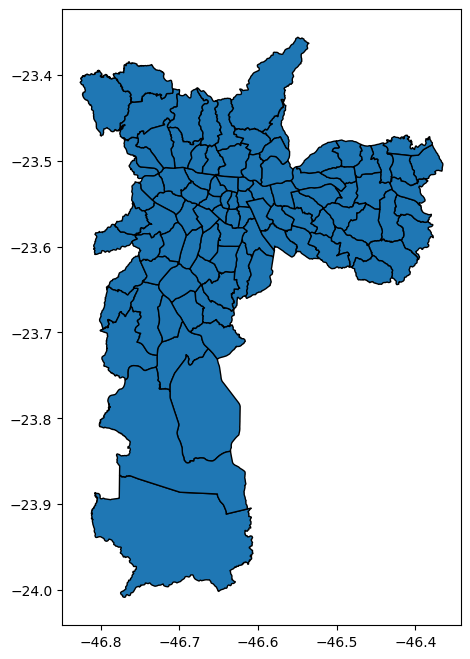

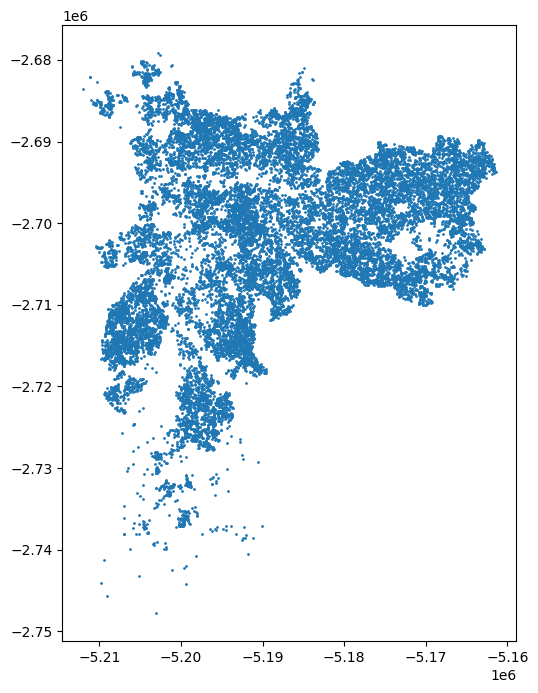

In [5]:
# Visualizações iniciais

localidade.plot(edgecolor="black", figsize=(8,8)) # Distritos de São Paulo
plt.show()

enderecos.plot(markersize=1, figsize=(8,8)) # Pontos localizados em São Paulo - residências e pontos comerciais
plt.show()

EPSG:3857


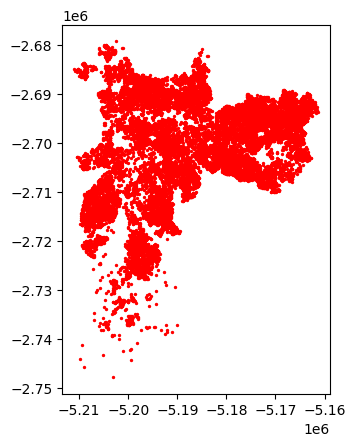

In [6]:
# Filtrar domicílios (apenas pontos que são residências)

domicilios = enderecos[enderecos["COD_ESP"] == 1].copy()

print(domicilios.crs)

domicilios.plot(color="red", markersize=2)
plt.show()

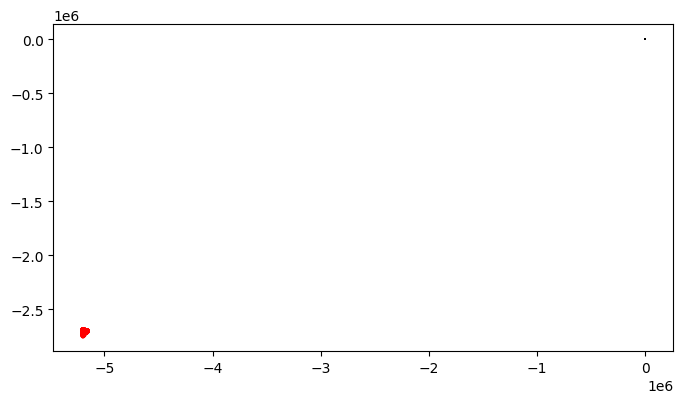

In [7]:
# Sobreposição - Pontos e Polígonos

ax = localidade.plot(facecolor="white",
                     edgecolor="black",
                     figsize=(8,8))

domicilios.plot(ax=ax,
                color="red",
                markersize=2)

plt.show()

In [8]:
# Mudança de projeção - O resultados acima não está adequado

localidade3857 = localidade.to_crs(3857)
domicilios3857 = domicilios.to_crs(3857)

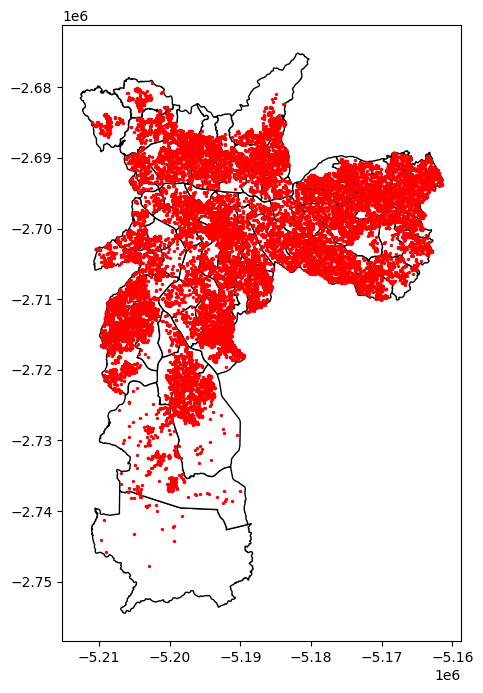

In [9]:
# Sobreposição - Pontos e Polígonos

ax = localidade3857.plot(facecolor="white",
                     edgecolor="black",
                     figsize=(8,8))

domicilios3857.plot(ax=ax,
                color="red",
                markersize=2)

plt.show()

In [10]:
# Contagem de domicílios por distrito

localidade3857 = localidade.to_crs(3857)
domicilios3857 = domicilios.to_crs(3857)

join = gpd.sjoin(
    domicilios3857,
    localidade3857,
    predicate="within",
    how="left")

contagem = join.groupby(join.index_right).size()

localidade3857["qtd_domicilios"] = (
    contagem.reindex(localidade3857.index)
    .fillna(0)
    .astype(int))

print(localidade3857["qtd_domicilios"].sum())
print(len(domicilios3857))

17094
17100


In [11]:
# Domicílios fora dos distritos

fora = join[join["index_right"].isna()].copy()

print(len(fora))

6


In [12]:
# Mapa Folium - Domicílios fora dos distritos

localidade4326 = localidade3857.to_crs(4326)
fora4326 = fora.to_crs(4326)

m = folium.Map(location=[-23.55,-46.63],
               zoom_start=10)

folium.GeoJson(localidade4326).add_to(m)

for _, row in fora4326.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y,row.geometry.x],
        radius=4,
        color="red",
        fill=True
    ).add_to(m)

m

In [13]:
# Estatísticas - Quantidade de domicílios por distrito

print(localidade3857["qtd_domicilios"].describe())

count     96.000000
mean     178.062500
std      110.677893
min        8.000000
25%      112.750000
50%      152.500000
75%      215.500000
max      643.000000
Name: qtd_domicilios, dtype: float64


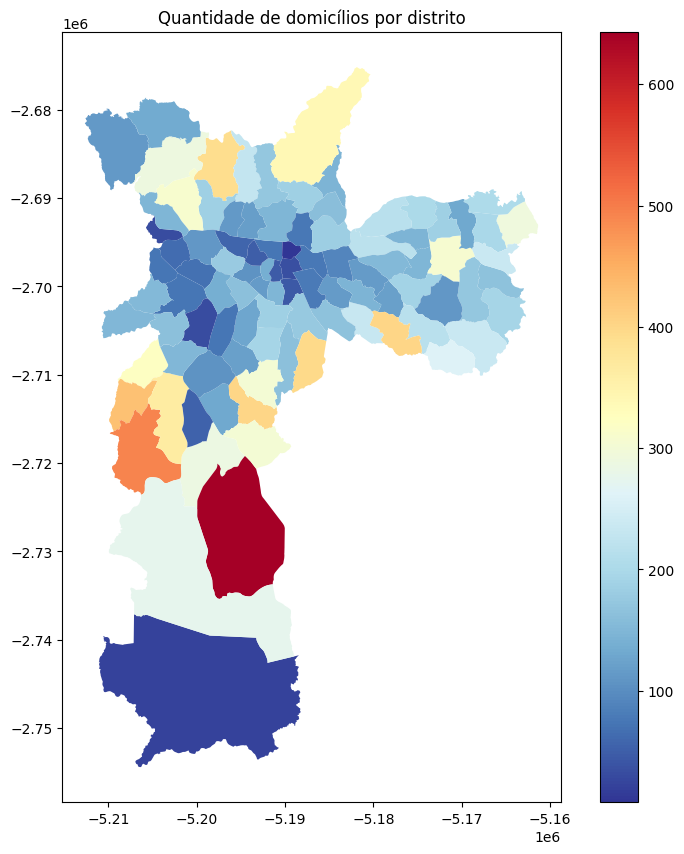

In [14]:
# Mapa contínuo - Mapa Coroplético

fig, ax = plt.subplots(figsize=(10,10))

localidade3857.plot(
    column="qtd_domicilios",
    cmap="RdYlBu_r",
    legend=True,
    ax=ax)

ax.set_title("Quantidade de domicílios por distrito")
plt.show()

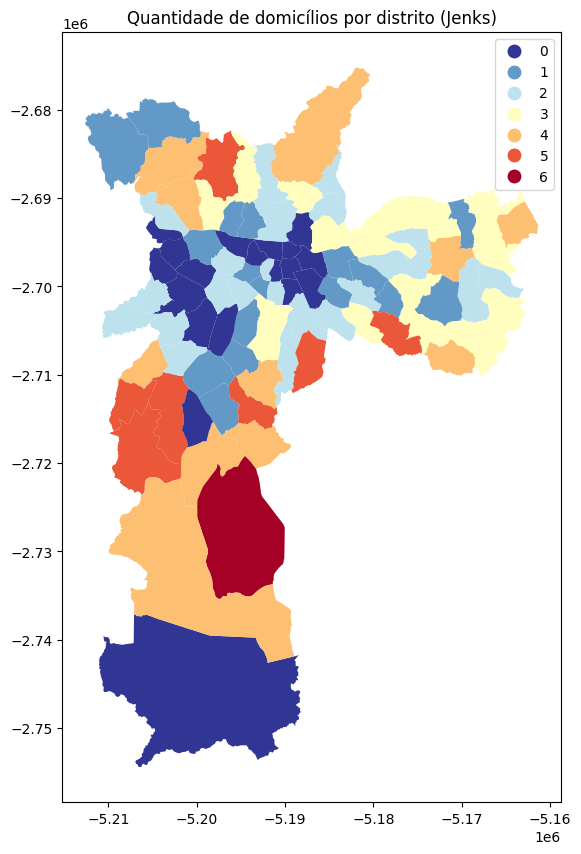

In [15]:
# Classificação Jenks

jenks = mapclassify.FisherJenks(
    localidade3857["qtd_domicilios"],
    k=7)

localidade3857["classe"] = jenks.yb

fig, ax = plt.subplots(figsize=(10,10))

localidade3857.plot(
    column="classe",
    cmap="RdYlBu_r",
    legend=True,
    categorical=True,
    ax=ax)

ax.set_title("Quantidade de domicílios por distrito (Jenks)")
plt.show()

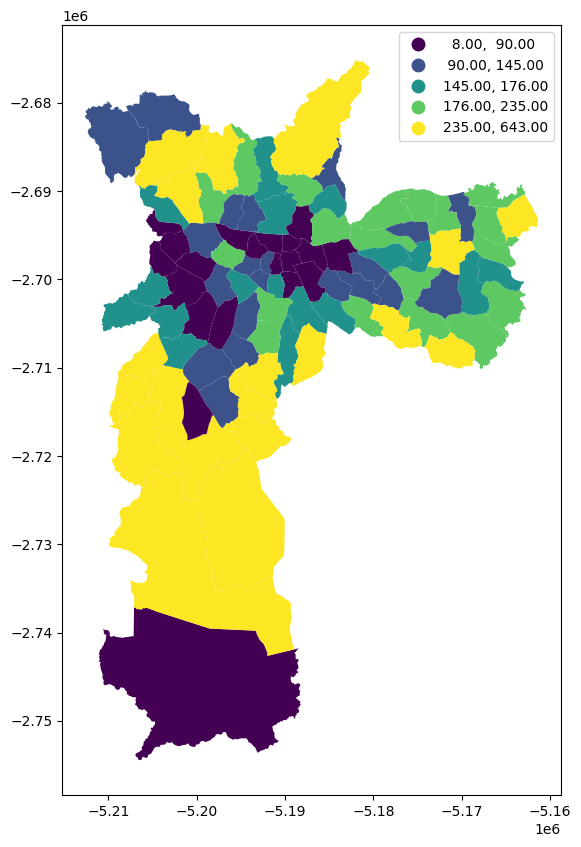

In [16]:
# Quantile

fig, ax = plt.subplots(figsize=(10,10))

localidade3857.plot(
    column="qtd_domicilios",
    scheme="Quantiles",
    k=5,
    cmap="viridis",
    legend=True,
    ax=ax)

plt.show()

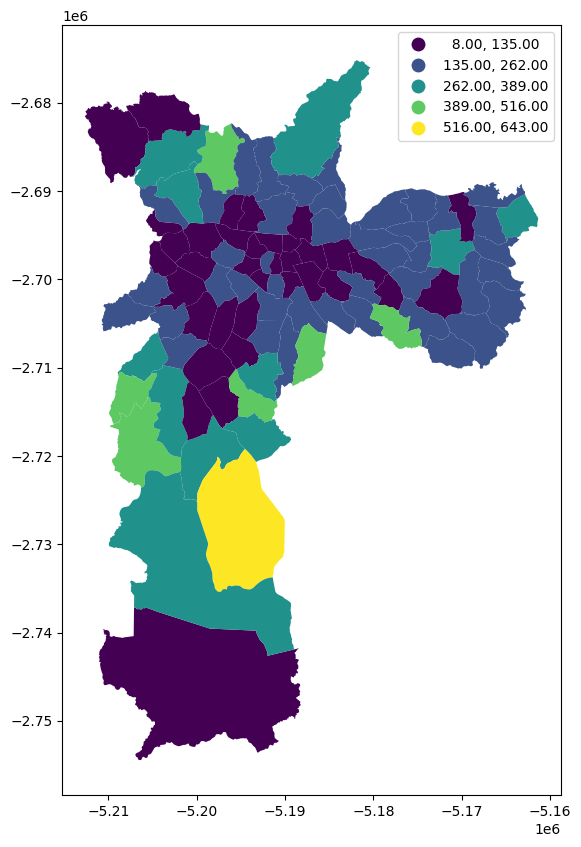

In [17]:
# Equal Interval

fig, ax = plt.subplots(figsize=(10,10))

localidade3857.plot(
    column="qtd_domicilios",
    scheme="EqualInterval",
    k=5,
    cmap="viridis",
    legend=True,
    ax=ax)

plt.show()

In [21]:
# Leaflet com todos os domicílios

domicilios4326 = domicilios3857.to_crs(4326)

m = folium.Map(location=[-23.55,-46.63],
               zoom_start=10)

folium.GeoJson(localidade4326).add_to(m)

for _, row in domicilios4326.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y,row.geometry.x],
        radius=2,
        color="red",
        fill=True,
        popup=str(row["COD_ESP"])
    ).add_to(m)

#m

In [22]:
# Filtrar um distrido - Perdizes

perdizes = localidade4326[
    localidade4326["NM_DIST"]=="Perdizes"
]

m = folium.Map(location=[-23.54,-46.68],
               zoom_start=13)

folium.GeoJson(
    perdizes,
    tooltip="Perdizes"
).add_to(m)

#m

In [23]:
# Filtrar um distrido - Morumbi

morumbi = localidade4326[
    localidade4326["NM_DIST"]=="Morumbi"
]

m = folium.Map(location=[-23.60,-46.72],
               zoom_start=13)

folium.GeoJson(
    morumbi,
    tooltip="Morumbi"
).add_to(m)

#m

In [25]:
# Mapa Coroplético

cmap = cm.linear.viridis.scale(
    localidade4326["qtd_domicilios"].min(),
    localidade4326["qtd_domicilios"].max())

m = folium.Map(location=[-23.55,-46.63],
               zoom_start=10)

folium.GeoJson(
    localidade4326,
    style_function=lambda feat: {
        "fillColor": cmap(
            feat["properties"]["qtd_domicilios"]
        ),
        "color":"white",
        "weight":1,
        "fillOpacity":0.7
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["NM_DIST","qtd_domicilios"]
    )
).add_to(m)

cmap.caption = "Quantidade de domicílios"
cmap.add_to(m)

#m

# **Manipulação de Dados Espaciais**

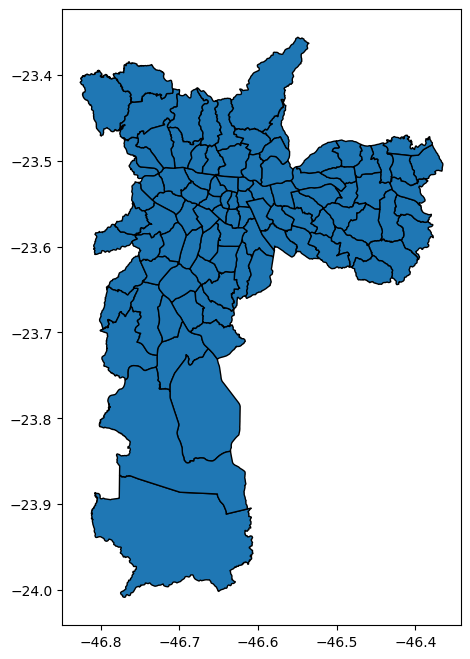

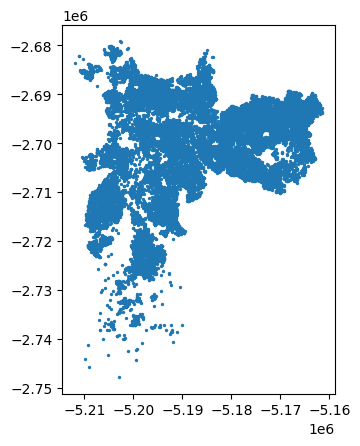

In [26]:

localidade.plot(edgecolor="black", figsize=(8,8))
plt.show()

enderecos.plot(markersize=2)
plt.show()

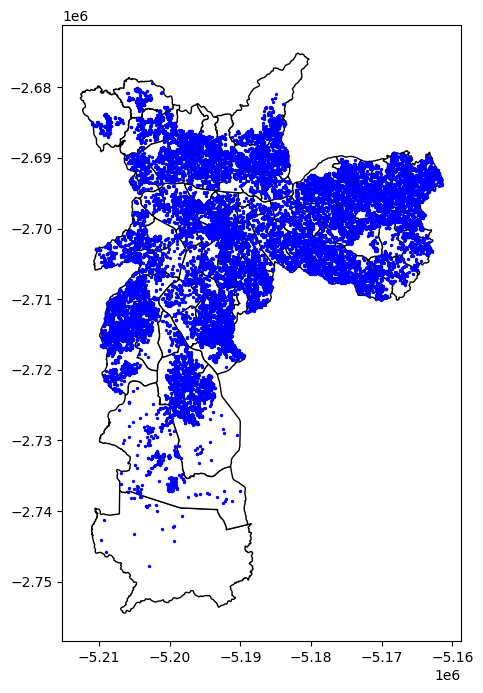

In [27]:
# Filtragem

domicilios = enderecos[enderecos["COD_ESP"] == 1].copy() # Apenas residências
estab_ensino = enderecos[enderecos["COD_ESP"] == 4].copy() # Apenas estabelecimentos de ensino
estab_saude = enderecos[enderecos["COD_ESP"] == 5].copy() # Apenas estabelecimentos de saúde

localidade3857 = localidade.to_crs(3857)
domicilios3857 = domicilios.to_crs(3857)

ax = localidade3857.plot(
    facecolor="white",
    edgecolor="black",
    figsize=(8,8))

domicilios3857.plot(
    ax=ax,
    color="blue",
    markersize=2)

plt.show()

In [28]:
# Predicados espaciais

localidade31983 = localidade.to_crs(31983)
estab_saude31983 = estab_saude.to_crs(31983)
estab_ensino31983 = estab_ensino.to_crs(31983)

# Within

within = gpd.sjoin(
    estab_saude31983,
    localidade31983,
    predicate="within",
    how="left")

print(within.head())

      COD_UF    COD_MUN  COD_ESP    ID         RENDA  \
11      35.0  3550308.0      5.0    12  16424.228071   
301     35.0  3550308.0      5.0   302   1409.932117   
902     35.0  3550308.0      5.0   903   5439.486510   
1542    35.0  3550308.0      5.0  1543   1979.020717   
2355    35.0  3550308.0      5.0  2356           NaN   

                            geometry  index_right   id CD_REGIAO NM_REGIAO  \
11    POINT (332139.871 7390577.765)           89  983         3   Sudeste   
301    POINT (356694.315 7391528.87)           24  918         3   Sudeste   
902   POINT (340640.573 7395444.374)           79  973         3   Sudeste   
1542  POINT (319751.597 7389430.535)           64  958         3   Sudeste   
2355  POINT (331071.674 7388722.606)           31  925         3   Sudeste   

      ...     NM_MUN    CD_DIST            NM_DIST CD_RGINT   NM_RGINT  \
11    ...  São Paulo  355030890       Vila Mariana     3501  São Paulo   
301   ...  São Paulo  355030825  Cidade Tirade

In [29]:
# Intersects

intersects = gpd.sjoin(
    estab_saude31983,
    localidade31983,
    predicate="intersects")

print(intersects.head())

      COD_UF    COD_MUN  COD_ESP    ID         RENDA  \
11      35.0  3550308.0      5.0    12  16424.228071   
301     35.0  3550308.0      5.0   302   1409.932117   
902     35.0  3550308.0      5.0   903   5439.486510   
1542    35.0  3550308.0      5.0  1543   1979.020717   
2355    35.0  3550308.0      5.0  2356           NaN   

                            geometry  index_right   id CD_REGIAO NM_REGIAO  \
11    POINT (332139.871 7390577.765)           89  983         3   Sudeste   
301    POINT (356694.315 7391528.87)           24  918         3   Sudeste   
902   POINT (340640.573 7395444.374)           79  973         3   Sudeste   
1542  POINT (319751.597 7389430.535)           64  958         3   Sudeste   
2355  POINT (331071.674 7388722.606)           31  925         3   Sudeste   

      ...     NM_MUN    CD_DIST            NM_DIST CD_RGINT   NM_RGINT  \
11    ...  São Paulo  355030890       Vila Mariana     3501  São Paulo   
301   ...  São Paulo  355030825  Cidade Tirade

In [30]:
# Contains

contains = gpd.sjoin(
    localidade31983,
    estab_ensino31983,
    predicate="contains")

print(contains.head())

     id CD_REGIAO NM_REGIAO CD_UF      NM_UF   CD_MUN     NM_MUN    CD_DIST  \
1   895         3   Sudeste    35  São Paulo  3550308  São Paulo  355030802   
5   899         3   Sudeste    35  São Paulo  3550308  São Paulo  355030806   
10  904         3   Sudeste    35  São Paulo  3550308  São Paulo  355030811   
11  905         3   Sudeste    35  São Paulo  3550308  São Paulo  355030812   
17  911         3   Sudeste    35  São Paulo  3550308  São Paulo  355030818   

              NM_DIST CD_RGINT  ... CD_CONCURB    NM_CONCURB QTD_ESCOLAS  \
1   Alto de Pinheiros     3501  ...    3550308  São Paulo/SP        26.0   
5         Barra Funda     3501  ...    3550308  São Paulo/SP        26.0   
10        Brasilândia     3501  ...    3550308  São Paulo/SP       170.0   
11            Butantã     3501  ...    3550308  São Paulo/SP        55.0   
17           Cangaiba     3501  ...    3550308  São Paulo/SP        88.0   

                                             geometry index_right  C

<Axes: >

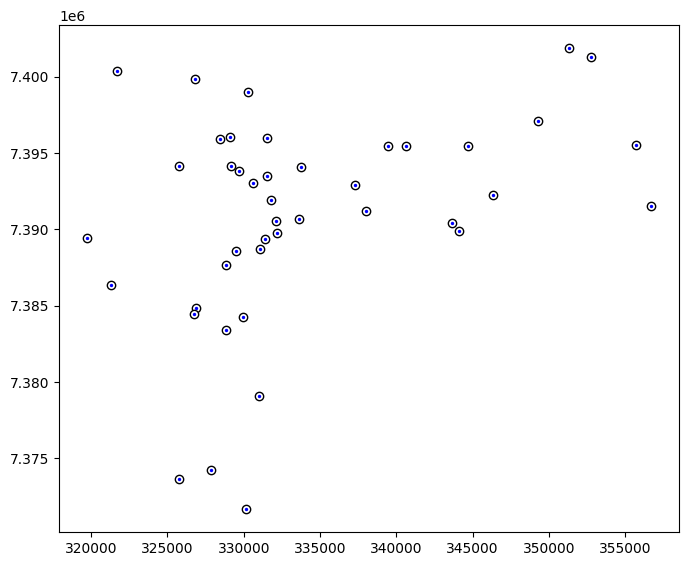

In [31]:
# Overlay

overlay = gpd.overlay(
    estab_saude31983,
    localidade31983,
    how="intersection")

ax = overlay.plot(
    facecolor="white",
    edgecolor="black",
    figsize=(8,8))

overlay.plot(
    ax=ax,
    color="blue",
    markersize=2)

/tmp/ipykernel_5156/4199378984.py:8: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ax = diferenca.plot(
/tmp/ipykernel_5156/4199378984.py:13: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  diferenca.plot(


<Axes: >

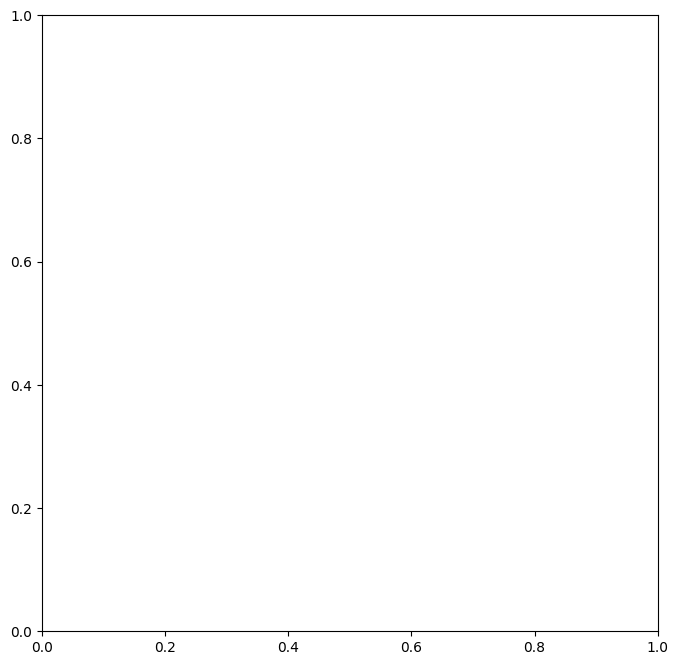

In [32]:
# Difference

diferenca = gpd.overlay(
    estab_saude31983,
    localidade31983,
    how="difference")

ax = diferenca.plot(
    facecolor="white",
    edgecolor="black",
    figsize=(8,8))

diferenca.plot(
    ax=ax,
    color="blue",
    markersize=2)

<Axes: >

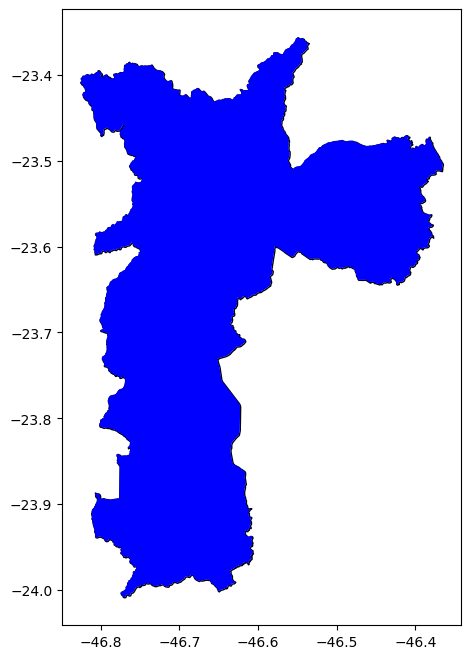

In [33]:
# União dos polígonos gerando um outro mapa

sp = localidade.dissolve()

ax = sp.plot(
    facecolor="white",
    edgecolor="black",
    figsize=(8,8))

sp.plot(
    ax=ax,
    color="blue",
    markersize=2)

In [34]:
# Área

localidade3857["area_km2_1"] = (
    localidade3857.area / 1_000_000
)

print(localidade3857.head())

    id CD_REGIAO NM_REGIAO CD_UF      NM_UF   CD_MUN     NM_MUN    CD_DIST  \
0  894         3   Sudeste    35  São Paulo  3550308  São Paulo  355030801   
1  895         3   Sudeste    35  São Paulo  3550308  São Paulo  355030802   
2  896         3   Sudeste    35  São Paulo  3550308  São Paulo  355030803   
3  897         3   Sudeste    35  São Paulo  3550308  São Paulo  355030804   
4  898         3   Sudeste    35  São Paulo  3550308  São Paulo  355030805   

             NM_DIST CD_RGINT   NM_RGINT  CD_RGI     NM_RGI CD_CONCURB  \
0          Água Rasa     3501  São Paulo  350001  São Paulo    3550308   
1  Alto de Pinheiros     3501  São Paulo  350001  São Paulo    3550308   
2         Anhanguera     3501  São Paulo  350001  São Paulo    3550308   
3         Aricanduva     3501  São Paulo  350001  São Paulo    3550308   
4        Artur Alvim     3501  São Paulo  350001  São Paulo    3550308   

     NM_CONCURB  QTD_ESCOLAS  \
0  São Paulo/SP         65.0   
1  São Paulo/SP       

In [35]:
# Área

localidade31983["area_km2_2"] = (
    localidade31983.area / 1_000_000
)

print(localidade31983.head()) # Projeções diferentes geram resultados distintos. Compare com os valores acima.

    id CD_REGIAO NM_REGIAO CD_UF      NM_UF   CD_MUN     NM_MUN    CD_DIST  \
0  894         3   Sudeste    35  São Paulo  3550308  São Paulo  355030801   
1  895         3   Sudeste    35  São Paulo  3550308  São Paulo  355030802   
2  896         3   Sudeste    35  São Paulo  3550308  São Paulo  355030803   
3  897         3   Sudeste    35  São Paulo  3550308  São Paulo  355030804   
4  898         3   Sudeste    35  São Paulo  3550308  São Paulo  355030805   

             NM_DIST CD_RGINT   NM_RGINT  CD_RGI     NM_RGI CD_CONCURB  \
0          Água Rasa     3501  São Paulo  350001  São Paulo    3550308   
1  Alto de Pinheiros     3501  São Paulo  350001  São Paulo    3550308   
2         Anhanguera     3501  São Paulo  350001  São Paulo    3550308   
3         Aricanduva     3501  São Paulo  350001  São Paulo    3550308   
4        Artur Alvim     3501  São Paulo  350001  São Paulo    3550308   

     NM_CONCURB  QTD_ESCOLAS  \
0  São Paulo/SP         65.0   
1  São Paulo/SP       

In [36]:
# Centróides

centroides = (
    localidade31983[["NM_DIST","geometry"]]
    .copy())

centroides.geometry = centroides.centroid

print(centroides.head())

             NM_DIST                        geometry
0          Água Rasa   POINT (339581.276 7392844.56)
1  Alto de Pinheiros  POINT (325261.109 7394818.388)
2         Anhanguera  POINT (316823.553 7407686.264)
3         Aricanduva   POINT (345323.01 7392126.289)
4        Artur Alvim  POINT (348330.779 7395891.307)


In [37]:
# Buffer de 1000 metros

estab_ensino31983 = estab_ensino.to_crs(31983)

area_influencia = estab_ensino31983.copy()

area_influencia.geometry = (
    area_influencia.buffer(1000))

print(area_influencia.head())

      COD_UF    COD_MUN  COD_ESP    ID        RENDA  \
1       35.0  3550308.0      4.0     2  5756.940929   
113     35.0  3550308.0      4.0   114  2203.684917   
914     35.0  3550308.0      4.0   915  5246.298924   
3441    35.0  3550308.0      4.0  3442  1935.944664   
4045    35.0  3550308.0      4.0  4046  4886.355021   

                                               geometry  
1     POLYGON ((330910.217 7396785.466, 330905.402 7...  
113   POLYGON ((331955.573 7400952.26, 331950.758 74...  
914   POLYGON ((337213.247 7391252.077, 337208.432 7...  
3441  POLYGON ((326697.017 7373661.133, 326692.202 7...  
4045  POLYGON ((340558.689 7396141.24, 340553.874 73...  


In [38]:
# Domicílios dentro do Buffer

inter_domicilios = gpd.overlay(
    domicilios.to_crs(31983),
    area_influencia,
    how="intersection"
)

duplicados = (
    inter_domicilios
    .groupby("ID_1")
    .size()
    .sort_values(ascending=False)
)

print(duplicados.head())

ID_1
7767     3
12939    3
8579     2
1833     2
1960     2
dtype: int64


In [39]:
# Buffer x Distritos

inter_buffer = gpd.overlay(
    area_influencia.to_crs(4326),
    localidade.to_crs(4326),
    how="intersection")

inter_buffer = (
    inter_buffer[
        ["ID","NM_DIST","geometry"]
    ])

print(inter_buffer.head())

    ID        NM_DIST                                           geometry
0    2    Barra Funda  POLYGON ((-46.67592 -23.53021, -46.67586 -23.5...
1    2     Consolação  POLYGON ((-46.66249 -23.53869, -46.6634 -23.53...
2    2       Perdizes  POLYGON ((-46.66433 -23.53919, -46.66528 -23.5...
3    2  Santa Cecília  POLYGON ((-46.6564 -23.5313, -46.65655 -23.532...
4  114     Casa Verde  POLYGON ((-46.64642 -23.49635, -46.64684 -23.4...


In [40]:
# Distâncias

ensino31983 = estab_ensino.to_crs(31983)
saude31983 = estab_saude.to_crs(31983)

distancias = ensino31983.geometry.apply(
    lambda g: saude31983.distance(g))

print(distancias)

              11            301           902           1542          2355   \
1       6595.977114  27295.049088  10813.836650  12541.634135   8146.085245   
113    10441.873027  27409.543945  11141.634767  16071.068615  12230.205493   
914     4128.812379  20482.938335   6097.258684  16562.123804   5730.096129   
3441   18102.011218  35778.324613  26416.272567  16852.954508  15991.713736   
4045    9273.139762  17745.524038   1286.893191  20913.021609  11272.336091   
4692    5845.451841  24166.123202  12770.988680  14442.813107   4521.484941   
5156   34101.573134  42214.595994  39667.311738  35559.407291  32298.319352   
5575   22936.560511   4039.764453  16149.606839  35201.264607  23862.079955   
6057    3291.490184  21358.070503   6693.720867  15704.366844   5015.111694   
6387   14176.968539  37417.576988  23959.832977   6707.894738  12299.038998   
6675    9761.077731  34111.516295  18254.557742   4299.189336   9336.505107   
7841   17712.853865   7973.399757  11792.984014  299

In [41]:
# Matriz de Distâncias

import numpy as np

matriz = np.zeros(
    (len(ensino31983), len(saude31983)))

for i, g1 in enumerate(ensino31983.geometry):

    matriz[i] = saude31983.distance(g1)

dist_pp = pd.DataFrame(
    matriz,
    index=ensino31983["ID"],
    columns=saude31983["ID"])

print(dist_pp.head())

ID           12            302           903           1543          2356   \
ID                                                                           
2      6595.977114  27295.049088  10813.836650  12541.634135   8146.085245   
114   10441.873027  27409.543945  11141.634767  16071.068615  12230.205493   
915    4128.812379  20482.938335   6097.258684  16562.123804   5730.096129   
3442  18102.011218  35778.324613  26416.272567  16852.954508  15991.713736   
4046   9273.139762  17745.524038   1286.893191  20913.021609  11272.336091   

ID           3191          3653          3675          4137          4446   \
ID                                                                           
2      1695.307455   1090.358727   4334.753593  13530.508381   2767.860442   
114    5623.078959   5241.047978   4266.929583  17505.115900   7062.874381   
915    9052.128035   8573.144672  12716.565649  15710.808866   7625.918191   
3442  22424.900344  22645.109761  26204.921887  13446.447183  2

# **Análises Espaciais Avançadas**

In [43]:
# Bibliotecas adicionais

import numpy as np
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
from scipy.interpolate import griddata
from shapely.geometry import Polygon
from scipy.spatial import Voronoi
from scipy.spatial import cKDTree

In [45]:
# Leitura dos dados
localidade = gpd.read_file("mapas/distritos_sp.gpkg").to_crs(31983)
domicilios = gpd.read_file("mapas/pontos_sp.shp")
domicilios = domicilios[domicilios["COD_ESP"] == 1].to_crs(31983)
pontos_venda = gpd.read_file("mapas/pdv_sp.gpkg").to_crs(31983)

In [46]:
# Buffer de 500 metros ao redor dos pontos de venda

pontos_venda31983 = pontos_venda.to_crs(31983)
area_influencia = pontos_venda31983.copy()
area_influencia.geometry = (
    area_influencia.buffer(500)
)

print(area_influencia.head())

  ID    FATURAM                                           geometry
0  1  76115.556  POLYGON ((333916.488 7391906.631, 333914.08 73...
1  2  24546.888  POLYGON ((337985.443 7402349.989, 337983.035 7...
2  3  14369.526  POLYGON ((353512.861 7389150.392, 353510.454 7...
3  4  41467.068  POLYGON ((334128.631 7403248.116, 334126.224 7...
4  5  10909.728  POLYGON ((326495.57 7404896.149, 326493.163 74...


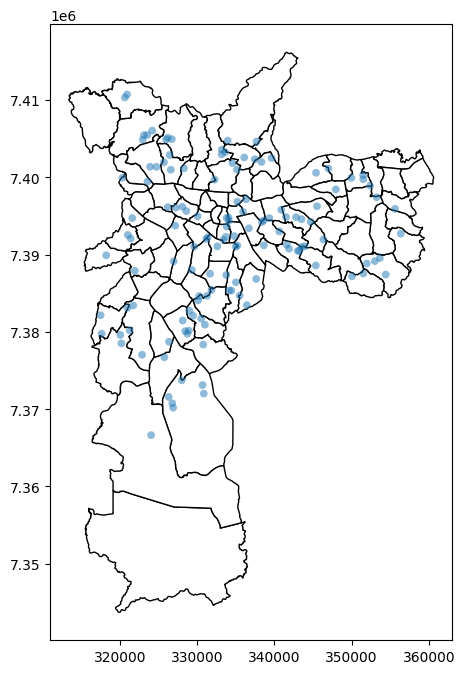

In [47]:
ax = localidade.plot(
    facecolor="white",
    edgecolor="black",
    figsize=(8,8)
)

area_influencia.plot(
    ax=ax,
    alpha=0.5
)

plt.show()

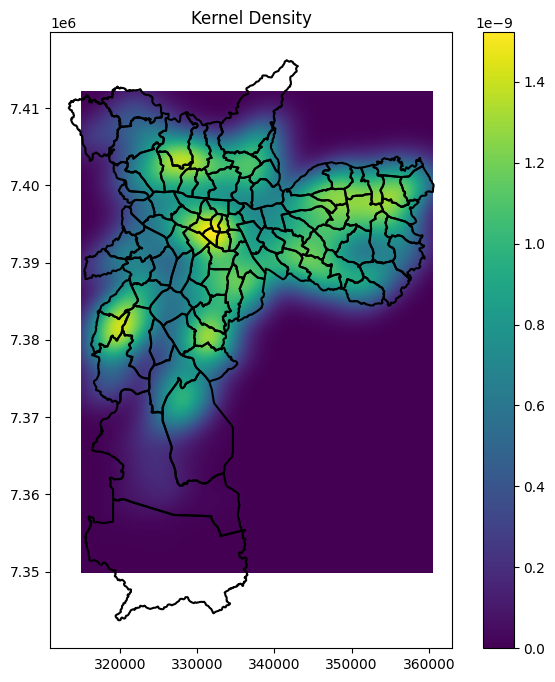

In [48]:
# Mapa de densidade de Kernel - Mapa de calor

x=domicilios.geometry.x
y=domicilios.geometry.y
xy=np.vstack([x,y])
kde=gaussian_kde(xy)

xmin,ymin,xmax,ymax=domicilios.total_bounds
xx,yy=np.mgrid[xmin:xmax:200j,ymin:ymax:200j]
z=kde(np.vstack([xx.ravel(),yy.ravel()])).reshape(xx.shape)

plt.figure(figsize=(8,8))
plt.imshow(z.T,origin='lower',extent=[xmin,xmax,ymin,ymax])
localidade.boundary.plot(ax=plt.gca(),color='black')
plt.title("Kernel Density")
plt.colorbar()
plt.show()

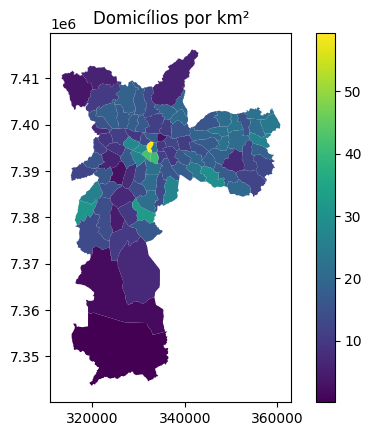

In [49]:
# Domicílios por km²

join=gpd.sjoin(domicilios,localidade,predicate='within')
cont=join.groupby('index_right').size()
localidade['qtd']=cont.reindex(localidade.index).fillna(0)
localidade['area_km2']=localidade.area/1e6
localidade['dens_km2']=localidade['qtd']/localidade['area_km2']
localidade.plot(column='dens_km2',legend=True,cmap='viridis')
plt.title("Domicílios por km²")
plt.show()

In [50]:
# Índice de Moran

from libpysal.weights import Queen
from esda.moran import Moran

w=Queen.from_dataframe(localidade)
w.transform='r'
mi=Moran(localidade['dens_km2'],w)
print("Moran I:",mi.I)
print("p-valor:",mi.p_sim)

/tmp/ipykernel_5156/50782438.py:6: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w=Queen.from_dataframe(localidade)


Moran I: 0.41139673144990846
p-valor: 0.001


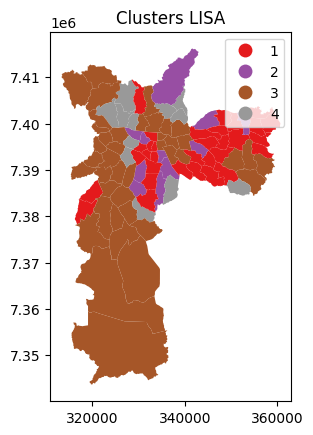

In [51]:
# Índice de Moran Local (LISA)

from esda.moran import Moran_Local

lisa=Moran_Local(localidade['dens_km2'],w)
localidade['cluster']=lisa.q
localidade.plot(column='cluster',categorical=True,legend=True,cmap='Set1')
plt.title("Clusters LISA")
plt.show()

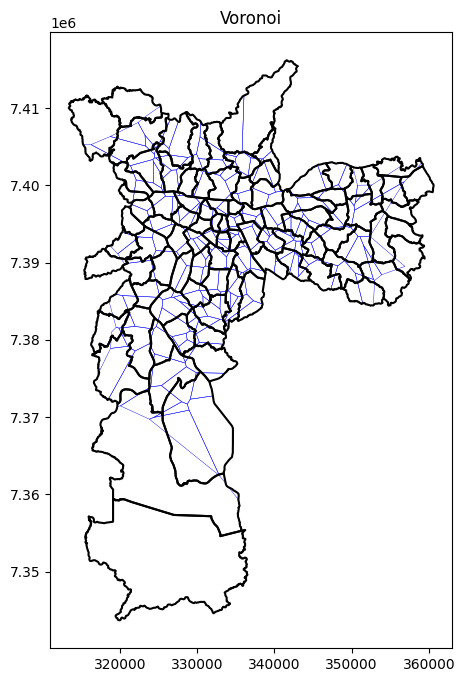

In [52]:
# Polígonos de Voronoi

pts=np.array([(g.x,g.y) for g in pontos_venda.geometry])
vor=Voronoi(pts)

polys=[]
for region in vor.regions:
    if not region or -1 in region:
        continue
    polys.append(Polygon(vor.vertices[region]))

vor_gdf=gpd.GeoDataFrame(geometry=polys,crs=domicilios.crs)
vor_gdf = gpd.overlay(vor_gdf, localidade, how="intersection")
ax=localidade.boundary.plot(figsize=(8,8),color='black')
vor_gdf.plot(ax=ax,facecolor='none',edgecolor='blue',linewidth=0.3)
plt.title("Voronoi")
plt.show()

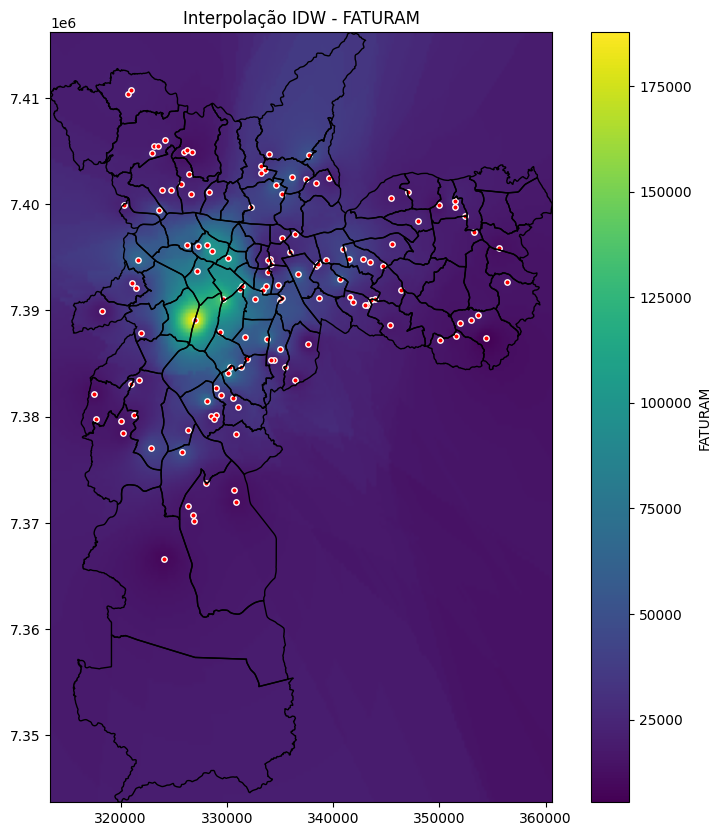

In [53]:
# Mapa de interpolação IDW (Inverse Distance Weighting)

x = pontos_venda.geometry.x.values
y = pontos_venda.geometry.y.values
z = pontos_venda["FATURAM"].values

xmin, ymin, xmax, ymax = localidade.total_bounds

res = 200

grid_x, grid_y = np.meshgrid(
    np.linspace(xmin, xmax, res),
    np.linspace(ymin, ymax, res))

grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel()))

# Potência do IDW

power = 2

# Número máximo de vizinhos utilizados

k = 12

tree = cKDTree(np.column_stack((x, y)))

dist, idx = tree.query(grid_points, k=k)

dist[dist == 0] = 1e-10
weights = 1 / (dist ** power)

idw = np.sum(weights * z[idx], axis=1) / np.sum(weights, axis=1)

idw = idw.reshape(grid_x.shape)

fig, ax = plt.subplots(figsize=(10,10))

im = ax.imshow(
    idw,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    cmap="viridis"
)

localidade.boundary.plot(ax=ax, color="black", linewidth=1)

pontos_venda.plot(
    ax=ax,
    color="red",
    markersize=15,
    edgecolor="white"
)

plt.colorbar(im, ax=ax, label="FATURAM")

ax.set_title("Interpolação IDW - FATURAM")

plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.9 MB/s eta 0:00:00


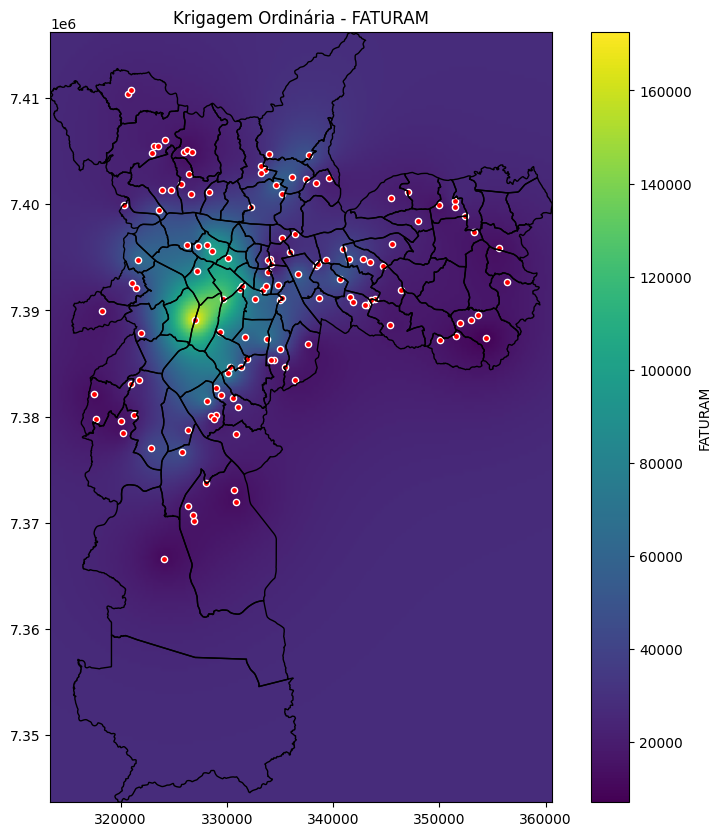

In [56]:
!pip install pykrige

from pykrige.ok import OrdinaryKriging

# Krigagem Ordinária (Ordinary Kriging)

import matplotlib.pyplot as plt

from pykrige.ok import OrdinaryKriging

x = pontos_venda.geometry.x.values
y = pontos_venda.geometry.y.values

z = pontos_venda["FATURAM"].values

xmin, ymin, xmax, ymax = localidade.total_bounds

gridx = np.linspace(xmin, xmax, 200)
gridy = np.linspace(ymin, ymax, 200)

OK = OrdinaryKriging(
    x,
    y,
    z,
    variogram_model="exponential",
    verbose=False,
    enable_plotting=False)

# Você também pode testar:
    # variogram_model="linear"
    # variogram_model="gaussian"
    # variogram_model="spherical"

z_krig, ss = OK.execute(
    "grid",
    gridx,
    gridy)

fig, ax = plt.subplots(figsize=(10,10))

im = ax.imshow(
    z_krig,
    extent=(xmin, xmax, ymin, ymax),
    origin="lower",
    cmap="viridis")

localidade.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1)

pontos_venda.plot(
    ax=ax,
    color="red",
    markersize=20,
    edgecolor="white")

plt.colorbar(im, ax=ax, label="FATURAM")

ax.set_title("Krigagem Ordinária - FATURAM")

plt.show()